In [11]:
import pandas as pd

# Assuming the CSV file is in the '/tmp/' directory. Adjust the path if needed.
try:
    df = pd.read_csv('/content/state_ofthe_union_texts.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: 'state_ofthe_union_texts.csv' not found. Please make sure the file is in the correct path.")
except Exception as e:
    print(f"An error occurred: {e}")

,President,Year,Title,Text
0,George Washington,1790,First State of the Union Address,['I embrace with great satisfaction the opport...
1,George Washington,1790,Second State of the Union Address,['Fellow-Citizens of the Senate and the House ...
2,George Washington,1791,Third State of the Union Address,['Fellow-Citizens of the Senate and the House ...
3,George Washington,1792,Fourth State of the Union Address,['Fellow-Citizens of the Senate and of the Hou...
4,George Washington,1793,Fifth State of the Union Address,['Fellow Citizens of the Senate and of the Hou...


In [12]:
# Create a DataFrame for the top 5 rows
top_5_df = df.head(5)
display(top_5_df)

,President,Year,Title,Text
0,George Washington,1790,First State of the Union Address,['I embrace with great satisfaction the opport...
1,George Washington,1790,Second State of the Union Address,['Fellow-Citizens of the Senate and the House ...
2,George Washington,1791,Third State of the Union Address,['Fellow-Citizens of the Senate and the House ...
3,George Washington,1792,Fourth State of the Union Address,['Fellow-Citizens of the Senate and of the Hou...
4,George Washington,1793,Fifth State of the Union Address,['Fellow Citizens of the Senate and of the Hou...


In [13]:
# Create a DataFrame for the bottom 5 rows
bottom_5_df = df.tail(5)
display(bottom_5_df)

,President,Year,Title,Text
214,Barack Obama,2015,Barack Obama's Seventh State of the Union Address,"['Mr. Speaker, Mr. Vice President, Members of ..."
215,Barack Obama,2016,Barack Obama's Eighth State of the Union Address,"['Mr. Speaker, Mr. Vice President, Members of ..."
216,Donald Trump,2017,Donald Trump's First State of the Union Address,"['Mr. Speaker, Mr. Vice President, Members of ..."
217,Donald Trump,2018,Donald Trump's Second State of the Union Address,"['Mr. Speaker, Mr. Vice President, Members of ..."
218,Donald Trump,2019,Donald Trump's Third State of the Union Address,"['Madam Speaker, Mr. Vice President, Members o..."


In [43]:
import re
import string
import nltk
from nltk.corpus import stopwords

# Download necessary NLTK data (run once)
nltk.download('stopwords', quiet=True)

# Concatenate speeches from the top 5 rows DataFrame
# Assuming the column containing the speech text is named 'Text'
top_5_speeches_text = ' '.join(top_5_df['Text'].astype(str))

# Preprocessing steps
# Convert to lowercase
top_5_speeches_text = top_5_speeches_text.lower()
# Remove punctuation
top_5_speeches_text = top_5_speeches_text.translate(str.maketrans('', '', string.punctuation))
# Remove numbers
top_5_speeches_text = re.sub(r'\d+', '', top_5_speeches_text)

# Tokenization using .split()
tokens = top_5_speeches_text.split()

# Remove stop words
stop_words = set(stopwords.words('english'))
# Add custom extra stopwords
extra_stopwords = {'may', 'upon', 'made', 'one', 'every',
                   'year', 'years', 'new', 'also', 'must',
                   'shall', 'said', 'make', 'great', 'can', 'would', 'will', 'now', 'let'}
stop_words.update(extra_stopwords)
filtered_tokens = [word for word in tokens if word not in stop_words]

# Remove short words (length <= 2)
long_tokens = [word for word in filtered_tokens if len(word) > 2]

# Join tokens back into a string for WordCloud (or further processing)
top_5_speeches_text = ' '.join(long_tokens)

print(f"Total length of preprocessed concatenated speeches from top 5 rows: {len(top_5_speeches_text)} characters")
print("First 200 characters of the preprocessed combined text from top 5 rows:")
print(top_5_speeches_text[:200])

Total length of preprocessed concatenated speeches from top 5 rows: 32830 characters
First 200 characters of the preprocessed combined text from top 5 rows:
embrace satisfaction opportunity presents congratulating present favourable prospects public affairs recent accession important state north carolina constitution united states official information rec


In [44]:
import re
import string
import nltk
from nltk.corpus import stopwords

# Download necessary NLTK data (run once)
nltk.download('stopwords', quiet=True)

# Concatenate speeches from the bottom 5 rows DataFrame
# Assuming the column containing the speech text is named 'Text'
bottom_5_speeches_text = ' '.join(bottom_5_df['Text'].astype(str))

# Preprocessing steps
# Convert to lowercase
bottom_5_speeches_text = bottom_5_speeches_text.lower()
# Remove punctuation
bottom_5_speeches_text = bottom_5_speeches_text.translate(str.maketrans('', '', string.punctuation))
# Remove numbers
bottom_5_speeches_text = re.sub(r'\d+', '', bottom_5_speeches_text)

# Tokenization using .split()
tokens = bottom_5_speeches_text.split()

# Remove stop words
stop_words = set(stopwords.words('english'))
# Add custom extra stopwords
extra_stopwords = {'may', 'upon', 'made', 'one', 'every',
                   'year', 'years', 'new', 'also', 'must',
                   'shall', 'said', 'make', 'great', 'can', 'would', 'will', 'now', 'let'}
stop_words.update(extra_stopwords)
filtered_tokens = [word for word in tokens if word not in stop_words]

# Remove short words (length <= 2)
long_tokens = [word for word in filtered_tokens if len(word) > 2]

# Join tokens back into a string for WordCloud (or further processing)
bottom_5_speeches_text = ' '.join(long_tokens)

print(f"Total length of preprocessed concatenated speeches from bottom 5 rows: {len(bottom_5_speeches_text)} characters")
print("First 200 characters of the preprocessed combined text from bottom 5 rows:")
print(bottom_5_speeches_text[:200])

Total length of preprocessed concatenated speeches from bottom 5 rows: 101455 characters
First 200 characters of the preprocessed combined text from bottom 5 rows:
speaker vice president members congress fellow americans fifteen century fifteen dawned terror touching shores unfolded generation fighting two long costly wars saw vicious recession spread across nat


In [42]:
from nltk.probability import FreqDist

# Tokenize the preprocessed text for top 5 speeches
tokens_top_5 = top_5_speeches_text.split()

# Calculate term frequencies for top 5 speeches
fdist_top_5 = FreqDist(tokens_top_5)

print("\nMost common terms in top 5 speeches:")
for word, frequency in fdist_top_5.most_common(10):
    print(f"{word}: {frequency}")

# Tokenize the preprocessed text for bottom 5 speeches
tokens_bottom_5 = bottom_5_speeches_text.split()

# Calculate term frequencies for bottom 5 speeches
fdist_bottom_5 = FreqDist(tokens_bottom_5)

print("\nMost common terms in bottom 5 speeches:")
for word, frequency in fdist_bottom_5.most_common(10):
    print(f"{word}: {frequency}")


Most common terms in top 5 speeches:
states: 53
united: 50
public: 32
government: 20
law: 20
measures: 19
present: 18
provision: 18
proper: 17
citizens: 17

Most common terms in bottom 5 speeches:
american: 126
america: 115
people: 93
americans: 89
country: 84
world: 76
tonight: 72
work: 72
time: 58
congress: 54


In [51]:
from nltk.probability import FreqDist

# Define the normalization mapping for domain-specific duplicates
normalization_map = {
    # America/Nation
    'american': 'america',
    'americans': 'america',
    'nation': 'america',
    'national': 'america',
    'country': 'america',

    # Government
    'government': 'government',
    'federal': 'government',

    # People
    'people': 'people',
    'citizen': 'people',
    'individuals': 'people',
}

# Apply normalization to the tokens from the top 5 speeches
normalized_tokens_top_5 = [normalization_map.get(token, token) for token in tokens_top_5]

# Apply normalization to the tokens from the bottom 5 speeches
normalized_tokens_bottom_5 = [normalization_map.get(token, token) for token in tokens_bottom_5]

print("Normalization applied: 'american' and 'americans' have been mapped to 'america'; 'law', 'policy', 'govermnet' to 'government'; 'citizen', 'individuals', 'workers' to 'people'; and 'united', 'states' to 'unitedstates'.")

# Recalculate term frequencies with the normalized tokens
fdist_normalized_top_5 = FreqDist(normalized_tokens_top_5)
fdist_normalized_bottom_5 = FreqDist(normalized_tokens_bottom_5)

print("\nMost common terms in top 5 speeches (after normalization):")
for word, frequency in fdist_normalized_top_5.most_common(10):
    print(f"{word}: {frequency}")

print("\nMost common terms in bottom 5 speeches (after normalization):")
for word, frequency in fdist_normalized_bottom_5.most_common(10):
    print(f"{word}: {frequency}")

Normalization applied: 'american' and 'americans' have been mapped to 'america'; 'law', 'policy', 'govermnet' to 'government'; 'citizen', 'individuals', 'workers' to 'people'; and 'united', 'states' to 'unitedstates'.

Most common terms in top 5 speeches (after normalization):
states: 53
united: 50
america: 36
public: 32
government: 21
law: 20
measures: 19
present: 18
provision: 18
proper: 17

Most common terms in bottom 5 speeches (after normalization):
america: 474
people: 101
world: 76
tonight: 72
work: 72
time: 58
congress: 54
want: 54
united: 52
jobs: 51


In [58]:
text_top_5 = ' '.join(normalized_tokens_top_5)
text_bottom_5 = ' '.join(normalized_tokens_bottom_5)

In [60]:
from wordcloud import WordCloud

wordcloud_top5 = WordCloud(
    width=800,
    height=800,
    background_color='white'
).generate(text_top_5)

wordcloud_bottom5 = WordCloud(
    width=800,
    height=800,
    background_color='white'
).generate(text_bottom_5)

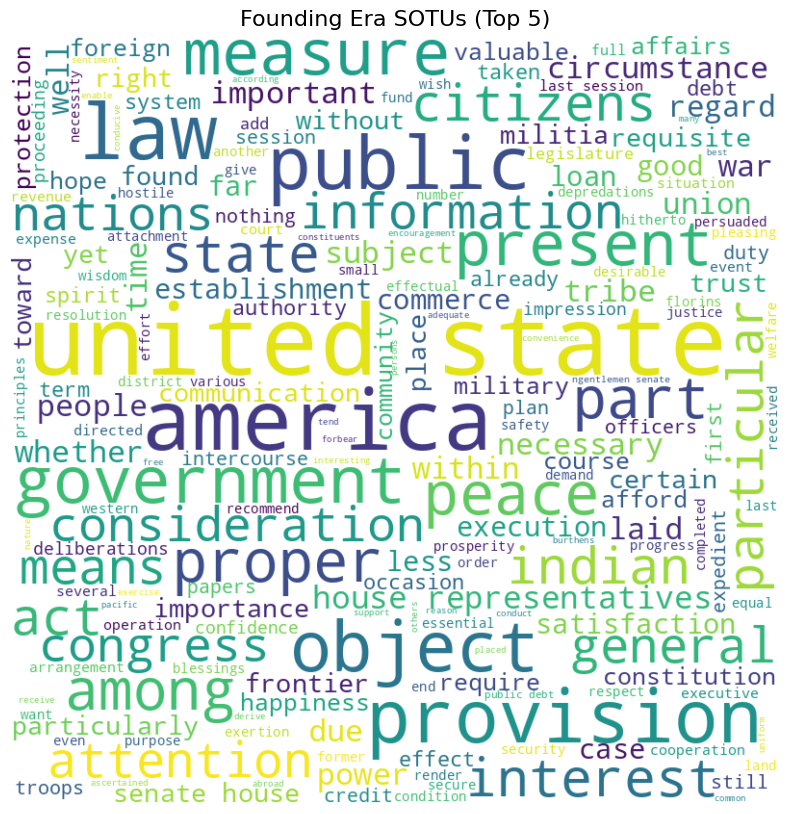

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_top5, interpolation='bilinear')
plt.axis('off')
plt.title('Founding Era SOTUs (Top 5)', fontsize=16)
plt.show()

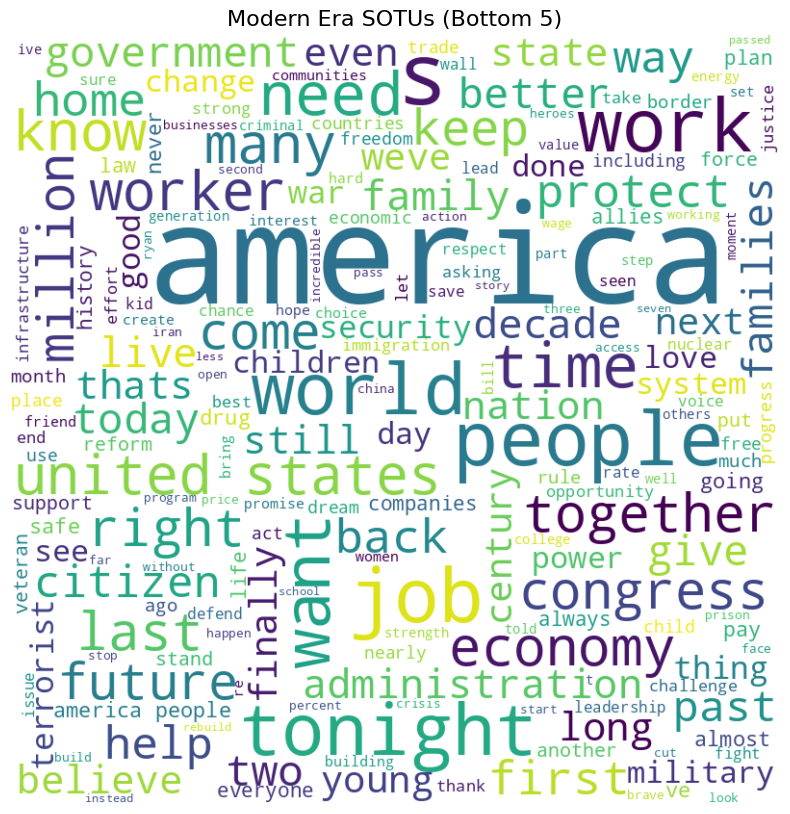

In [62]:
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_bottom5, interpolation='bilinear')
plt.axis('off')
plt.title('Modern Era SOTUs (Bottom 5)', fontsize=16)
plt.show()